<a href="https://colab.research.google.com/github/bellakinch/TruthSeeker-News-Analysis-/blob/main/TruthSeeker_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training samples : 107358
Test samples     : 26840
Features         : 1020


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9693 - loss: 0.0828 - val_accuracy: 0.9927 - val_loss: 0.0290
Epoch 2/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9957 - loss: 0.0162 - val_accuracy: 0.9946 - val_loss: 0.0164
Epoch 3/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9981 - loss: 0.0071 - val_accuracy: 0.9975 - val_loss: 0.0086
Epoch 4/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9984 - loss: 0.0048 - val_accuracy: 0.9973 - val_loss: 0.0075
Epoch 5/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9992 - loss: 0.0080 - val_accuracy: 0.9984 - val_loss: 0.0043
Epoch 6/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9998 - loss: 3.9064e-04 - val_accuracy: 0.9988 - val_loss: 0.0042
Epoch 7/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 1.0000 - loss: 1.2621e-04 - val_accuracy: 0.9990 - val_loss: 0.0040
Epoch 8/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 1.0000 - loss: 4

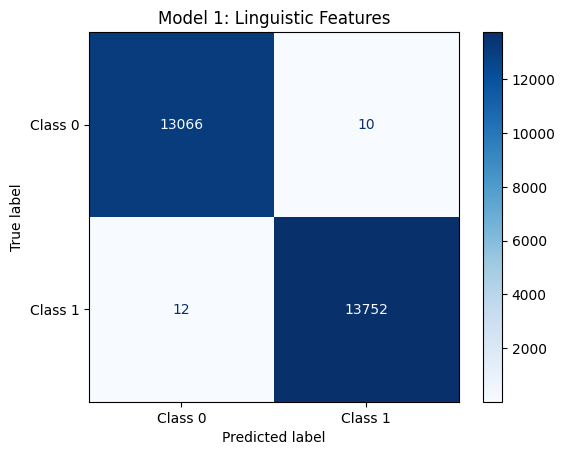

Training samples : 107358
Test samples     : 26840
Features         : 9
Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1342/1342 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5547 - loss: 0.6814 - val_accuracy: 0.5545 - val_loss: 0.6816
Epoch 2/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5599 - loss: 0.6798 - val_accuracy: 0.5538 - val_loss: 0.6803
Epoch 3/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5609 - loss: 0.6790 - val_accuracy: 0.5555 - val_loss: 0.6801
Epoch 4/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5617 - loss: 0.6785 - val_accuracy: 0.5562 - val_loss: 0.6794
Epoch 5/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5621 - loss: 0.6781 - val_accuracy: 0.5603 - val_loss: 0.6789
Epoch 6/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5633 - loss: 0.6776 - val_accuracy: 0.5614 - val_loss: 0.6779
Epoch 7/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5663 - loss: 0.6772 - val_accuracy: 0.5649 - val_loss: 0.6786
Epoch 8/50
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5670 - loss: 0.6768 - val_accurac

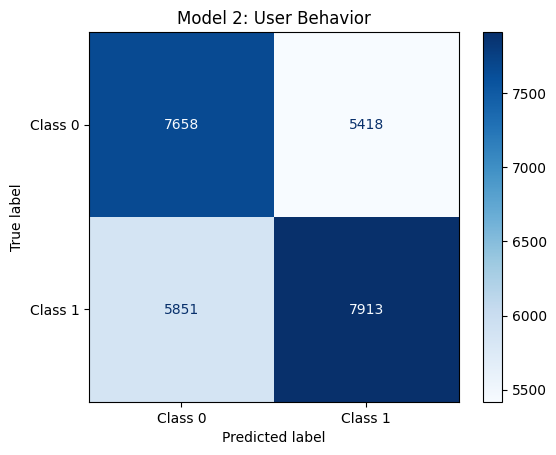

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------- LOAD DATASET -----------
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Features_For_Traditional_ML_Techniques (1).csv')

# --------- CLEAN/ PREP DATA -----------
# Drop rows with missing values
data = df
data.dropna(inplace=True)
data.shape

# Set Model 1 features - linguistsic
linguistic_features = [
    'tweet', 'statement',
    'unique_count', 'total_count',
    'Max word length', 'Average word length',
    'present_verbs', 'past_verbs',
    'adjectives', 'pronouns', 'TOs', 'determiners',
    'conjunctions', 'dots', 'exclamation', 'questions',
    'ampersand', 'capitals', 'digits',
    'long_word_freq', 'short_word_freq', 'Min word length'
]

# Set Model 2 features - meta data
behavior_features = [
    'followers_count', 'friends_count', 'statuses_count',
    'BotScore', 'normalize_influence', 'replies',
    'cred', 'retweets', 'favourites_count'
]

# Drop rows with missing values in the assigned columns.
required_columns = (
    ['BinaryNumTarget'] + linguistic_features + behavior_features)

data = data.dropna(subset=required_columns).copy()

# -------  MODEL #1 LINGUISTIC ----------------
# Define features and target
# tweet and statement are already in linguistic_features.
X = data[linguistic_features]
y = data['BinaryNumTarget'].astype(int)

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Only numerical columns go into StandardScaler
numeric_features = [column for column in linguistic_features
     if column not in ['tweet', 'statement']]

# Scale numerical features
scaler = StandardScaler()
X_train_numbers = scaler.fit_transform(X_train_raw[numeric_features])
X_test_numbers = scaler.transform(X_test_raw[numeric_features])

# Convert tweet text into numbers
tweet_vectorizer = TfidfVectorizer(max_features=500, dtype=np.float32)
X_train_tweet = tweet_vectorizer.fit_transform(X_train_raw['tweet'].astype(str)).toarray()
X_test_tweet = tweet_vectorizer.transform(X_test_raw['tweet'].astype(str)).toarray()

# Convert statement text into numbers
statement_vectorizer = TfidfVectorizer(max_features=500, dtype=np.float32)
X_train_statement = statement_vectorizer.fit_transform(X_train_raw['statement'].astype(str)).toarray()
X_test_statement = statement_vectorizer.transform(X_test_raw['statement'].astype(str)).toarray()

# Combine numerical and text features
X_train = np.hstack([X_train_numbers, X_train_tweet, X_train_statement]).astype('float32')
X_test = np.hstack([X_test_numbers, X_test_tweet, X_test_statement]).astype('float32')

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

# Initialize the model
model1 = Sequential()

# Hidden layer 1: 64 neurons
model1.add(Dense(
    64, activation='relu',
    input_shape=(X_train.shape[1],)))

# Hidden layer 2: 32 neurons
model1.add(Dense(32, activation='relu'))

# Hidden layer 3: 16 neurons
model1.add(Dense(16, activation='relu'))

# Output layer
model1.add(Dense(1, activation='sigmoid'))

# Compile the model
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

# Train
history1 = model1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1)

# Evaluate on the unseen test set
test_loss1, test_acc1 = model1.evaluate(X_test, y_test)
print(f"\nModel 1 Test Accuracy: {test_acc1:.4f}")

# Confusion matrix
y_pred1 = (model1.predict(X_test, verbose=0).ravel() >= 0.5).astype(int)
cm1 = confusion_matrix(y_test, y_pred1, labels=[0, 1])
print(cm1)

ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=['Class 0', 'Class 1']
).plot(cmap='Blues')

plt.title('Model 1: Linguistic Features')
plt.show()

# ------- ALL OF MODEL #2 META DATA ----------------
# Define features and Y target
X = data[behavior_features]
y = data['BinaryNumTarget'].astype(int)

# Train/test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw).astype('float32')
X_test = scaler.transform(X_test_raw).astype('float32')

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

# Initialize the model
model2 = Sequential()

# Hidden layer 1: 64 neurons
model2.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden layer 2: 32 neurons
model2.add(Dense(32, activation='relu'))

# Hidden layer 3: 16 neurons
model2.add(Dense(16, activation='relu'))

# Output layer.
model2.add(Dense(1, activation='sigmoid'))

# Compile the model.
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model.
history2 = model2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate on the unseen test set
test_loss2, test_acc2 = model2.evaluate(X_test, y_test)
print(f"\nModel 2 Test Accuracy: {test_acc2:.4f}")

# Confusion matrix
y_pred2 = (model2.predict(X_test, verbose=0).ravel() >= 0.5).astype(int)
cm2 = confusion_matrix(y_test, y_pred2, labels=[0, 1])
print(cm2)

ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=['Class 0', 'Class 1']
).plot(cmap='Blues')

plt.title('Model 2: User Behavior')
plt.show()


This is a build of a neural network model with 3 hidden layers for the truth seeker dataset.
The goal of this model is to classify tweets as true or false based on
1. linguistic features.
2. User behavior


MODEL #1 - Linguistic Features


---


The confusion matrix showed 13,066 correct class 0 (false) predictions and 13,752 correct class 1(true)  predictions. Only 22 examples were misclassified: 10 false examples were predicted as true , and 12 true examples were predicted as class 0. These results indicate strong performance for both classes on this test split.

The model reached close to 100% training accuracy and 99.94% validation accuracy. Repeated statements have appeared in both training and testing, allowing the model to recognize familiar claims.


MODEL #2 - Metadata


---

The confusion matrix showed 7,658 correct class 0(false) predictions and 7,913 correct class 1 (true) predictions. However, 5,418 class 0 examples were incorrectly predicted as class 1, and 5,851 class 1 examples were incorrectly predicted as class 0. These errors show that the model had a struggle to distinguish both classes.
The final training accuracy was 58.47%, and validation accuracy was 57.34%. This means that model has a 58% accuracy when using metadata features to predict if the statements are true or false and a 57% accuracy when it comes to correctly predicting the


Conclusion


---


Overall, Model 1 performed better at predicting true or false on the test split, achieving 99.92% accuracy while Model 2 has a 58.01% accuracy. This can tell us that text and linguistic features can provide more useful information and prediction if true or false than user behavior features/ meta data in this machine learning. It's important to note that Model 1 high accuracy does not automatically prove overfitting. This is because its training, validation, and test accuracies were similar. However, repeated statements may have appeared many times within the splits, allowing the model to remember repeating statements. Testing on entirely new statements/ datasets would help determine whether its strong performance generalizes.


